In [1]:
using ITensors, ITensorMPS, LinearAlgebra

In [17]:
"""
Functions for initializing the whip circuit
"""
function make_1d_whip_gates(nbits::Int64, theta::Float64, sites::Vector{Index{Int64}}, use_loop_op=true)
    if nbits == 2
        angles = Array([theta*2])
        indices = [(1,nbits)]
    else
        if use_loop_op
            indices = [(1,nbits)]
            angles = zeros(Float64, nbits)
            angles[1] = theta
            angles[2:end-1] .= theta*2
            angles[end] = theta
        else
            indices = []
            angles = zeros(Float64, nbits-1)
            angles .= theta*2
        end
        for i in 1:nbits-1
            push!(indices, (i,i+1))
        end
    end
    @assert length(angles) == length(indices)
    gates = ITensor[]
    for i in eachindex(indices)
        s_1, s_2 = indices[i]
        a = angles[i]
        T2 = op("Z",sites[s_1]) * op("Y",sites[s_2])
        G = exp(-1im * a / 2 * T2) # need divided by 2
        push!(gates, G)
    end
    return gates
end

make_1d_whip_gates

In [18]:
# ==== ====
"""
Functions for projecting back to the computational basis
"""
function get_statevector_from_mps(nbits::Int, mps::MPS)
    _sites = siteinds(mps)
    # statevec = zeros(typeof(mps[1][1]), 2^nbits)
    statevec = zeros(ComplexF64, 2^nbits)
    for i in eachindex(statevec)
        bit = string(i-1, base = 2, pad = nbits) # index to basis state
        # j = parse(Int, join(new_bit), base=2) + 1# basis state to index
        # construct mps based on bitstring
        bitstring = split(bit, "")
        imps = MPS(_sites, bitstring)
        # calculate the inner product
        val = inner(imps, mps)
        statevec[i] = val
    end
    statevec
end

get_int(s) = parse(Int, s, base=2)
get_bit(idx, n) = string(idx, base=2, pad=n)

"""
Find the nonzero bitstring
"""
function check_ground_state_configuration(mps::MPS)
    println(inner(mps,mps))
    nbits = length(mps)
    if nbits >= 20
        return print("System size is too large")
    end
    psivec = get_statevector_from_mps(nbits, mps)
    nz_loc = []
    for i in eachindex(psivec)
        if isapprox(psivec[i], 0, atol=1E-14)
            continue
        else
            push!(nz_loc, i)
        end
    end
    get_bit.(nz_loc.-1, nbits), psivec[nz_loc]
end

"""
Entanglement entropy
https://docs.itensor.org/ITensorMPS/stable/examples/MPSandMPO.html#Computing-the-Entanglement-Entropy-of-an-MPS
"""
function entanglement_entropy_svd(mps::MPS, cut_bond)
    b = cut_bond #Int(N/2)
    mps_copy = orthogonalize(mps, b)
    # The reduced density matrix eigenvalues are the squares of the
    # Schmidt coefficients, which are the singular values
    # U,S,V = svd(mps_copy[b], (linkinds(mps_copy, b-1)..., siteinds(mps_copy, b)...))
    U,S,V = svd(mps_copy[b], (siteinds(mps_copy, b)...,linkinds(mps_copy, b-1)...))
    # Extract Schmidt coefficients (singular values)
    S_vN = 0.0
    for n=1:dim(S, 1)
      p = S[n,n]^2   # Probability = |coefficient|^2
    #   if p > 1E-16 # Avoid log(0)
          S_vN -= p * log2(p)
    #   end
    end
    S_vN
end

entanglement_entropy_svd

In [50]:
# system parameters
N = 6
use_loop_op = true
# whip angle
theta = pi/9
# svd cutoff
l_cutoff = 1E-8
# Initialize the sites
sites = siteinds("Qubit", N)
# Create the quantum circuit gates
gates = make_1d_whip_gates(N, theta, sites, use_loop_op);

In [51]:
# 000 state
states = ["0" for n in 1:N]
ket0 = MPS(sites, states);
# +++ state
states = ["+" for n in 1:N]
psi0 = MPS(sites, states);

In [52]:
# apply gates
psi = apply(gates, psi0; cutoff=l_cutoff);
println(" ", maxlinkdim(psi))

 4


In [53]:
L = psi[2] 
Ldag = dag(prime(psi[2], commoninds(psi[2],psi[3])))
display(inds(L))
display(inds(Ldag))
array(L*Ldag)

((dim=2|id=984|"Qubit,Site,n=2"), (dim=2|id=297|"Link,n=1"), (dim=4|id=341|"Link,n=1"))

((dim=2|id=984|"Qubit,Site,n=2"), (dim=2|id=297|"Link,n=1"), (dim=4|id=341|"Link,n=1")')

4×4 Matrix{ComplexF64}:
          1.0+0.0im  -3.60976e-16+0.0im  …   2.65144e-16+0.0im
 -3.60976e-16+0.0im           1.0+0.0im     -4.46423e-16+0.0im
     4.69e-16+0.0im   1.49626e-17+0.0im     -4.90737e-17+0.0im
  2.65144e-16+0.0im  -4.46423e-16+0.0im              1.0+0.0im

In [54]:
println(cos(theta/2)/sqrt(2)," ",sin(theta/2)/sqrt(2))
println(cos(theta/2)^2/sqrt(2)," ",sin(theta/2)*cos(theta/2)/sqrt(2)," ",sin(theta/2)^2/sqrt(2))

0.6963642403200189 0.12278780396897282
0.685784902787611 0.1209223813239876 0.021321878398936407


In [55]:
orthogonalize!(psi, 3)
display(inds(psi[1]))
display(array(psi[1]))
display(inds(psi[2]))
display(array(psi[2]))
display(inds(psi[3]))
display(array(psi[3]))
display("===")
display(inds(psi[4]))
display(array(psi[4]))
display(inds(psi[5]))
display(array(psi[5]))
display(inds(psi[6]))
display(array(psi[6]))
# display(array(psi[end]))

((dim=2|id=864|"Qubit,Site,n=1"), (dim=2|id=297|"Link,n=1"))

2×2 Matrix{ComplexF64}:
 0.707107+0.0im  -0.707107+0.0im
 0.707107+0.0im   0.707107+0.0im

((dim=2|id=984|"Qubit,Site,n=2"), (dim=2|id=297|"Link,n=1"), (dim=4|id=341|"Link,n=1"))

2×2×4 Array{ComplexF64, 3}:
[:, :, 1] =
 -0.663971+0.0im  -0.243193+0.0im
 -0.663971+0.0im   0.243193-0.0im

[:, :, 2] =
  0.6313+0.0im  0.318528+0.0im
 -0.6313+0.0im  0.318528-0.0im

[:, :, 3] =
  0.318528+0.0im  -0.6313+0.0im
 -0.318528+0.0im  -0.6313-0.0im

[:, :, 4] =
 0.243193+0.0im  -0.663971+0.0im
 0.243193+0.0im   0.663971+0.0im

((dim=2|id=715|"Qubit,Site,n=3"), (dim=4|id=341|"Link,n=1"), (dim=4|id=63|"Link,n=1"))

...

2×4×4 Array{ComplexF64, 3}:
[:, :, 1] =
 -0.664241+0.0im  -0.24144+0.0im   0.021596+0.0im  -0.00493167+0.0im
 -0.664241+0.0im   0.24144+0.0im  -0.021596+0.0im  -0.00493167+0.0im

[:, :, 2] =
  0.646156+0.0im  0.25738+0.0im  0.118572+0.0im  -0.0466695+0.0im
 -0.646156+0.0im  0.25738+0.0im  0.118572+0.0im   0.0466695+0.0im

[:, :, 3] =
  0.154535+0.0im  -0.0472331+0.0im  -0.646115+0.0im   0.237535+0.0im
 -0.154535+0.0im  -0.0472331+0.0im  -0.646115+0.0im  -0.237535+0.0im

[:, :, 4] =
 -0.013535+0.0im   0.100907+0.0im   0.65655+0.0im  -0.242026+0.0im
 -0.013535+0.0im  -0.100907+0.0im  -0.65655+0.0im  -0.242026+0.0im

((dim=2|id=792|"Qubit,Site,n=5"), (dim=2|id=384|"Link,n=1"), (dim=4|id=986|"Link,n=1"))

2×2×4 Array{ComplexF64, 3}:
[:, :, 1] =
 -0.694162+0.0im   0.134683+0.0im
 -0.694162+0.0im  -0.134683+0.0im

[:, :, 2] =
  0.667399+0.0im  -0.23362+0.0im
 -0.667399+0.0im  -0.23362+0.0im

[:, :, 3] =
 -0.23362+0.0im  -0.667399+0.0im
  0.23362+0.0im  -0.667399+0.0im

[:, :, 4] =
 -0.134683+0.0im  -0.694162+0.0im
 -0.134683+0.0im   0.694162+0.0im

((dim=2|id=947|"Qubit,Site,n=6"), (dim=2|id=384|"Link,n=1"))

2×2 Matrix{ComplexF64}:
 -0.707107+0.0im  -0.707107+0.0im
 -0.707107+0.0im   0.707107+0.0im

In [93]:
# check the ground state configuration
loc, coeff = check_ground_state_configuration(psi)
# reshape([loc; coeff], :, 2)

0.9999999999999994 + 0.0im


(["010100", "010101", "101010", "101011"], ComplexF64[0.2705980500730985 + 0.0im, 0.6532814824381885 + 0.0im, 0.6532814824381877 + 0.0im, 0.27059805007309806 + 0.0im])

In [72]:
# check the entanglement entropy
entanglement_entropy_svd(psi, Int(N/2))

0.6008760366928574

In [73]:
# Details of svd
b = Int(N/2)
tmp = orthogonalize(psi, b)
T = tmp[b]
comb_1 = combiner(siteinds(psi, b)...,linkinds(psi, b-1)...)
T = comb_1 * T
display(array(T))
# u,d,v = svd(T, inds(comb_1))
# array(u)
# array(u)' * array(u)
u,d,v = svd(array(T),full=false)
u

ErrorException: Trying to contract a tensor with indices:

((dim=2|id=663|"Qubit,Site,n=4"), (dim=2|id=189|"Link,n=1"), (dim=2|id=640|"Link,n=1"))

and labels:

(-1, 4, 5)

with a combiner tensor with indices:

((dim=4|id=393|"CMB,Link"), (dim=2|id=663|"Qubit,Site,n=4"), (dim=2|id=670|"Link,n=1"))

and labels:

(2, -1, 3).

This is not a valid combiner contraction.

If you are combining, the combined index of the combiner should be the only one uncontracted.

If you are uncombining, the combined index of the combiner should be the only one contracted.

By convention, the combined index should be the index in position 1 of the combiner tensor.


## Calculate $S$ as a function of $\theta$

In [40]:
using CairoMakie
using Makie.Colors
using Printf

In [49]:
# system parameters
N = 100
use_loop_op = true
# svd cutoff
l_cutoff = 0 #1E-8
# Initialize the sites
sites = siteinds("Qubit", N)
states = ["+" for n in 1:N]
psi0 = MPS(sites, states);

In [50]:
thetas = [i for i in -1:0.01:1] .* pi/2
println(thetas)
S = zeros(Float64, length(thetas))
for (i, theta) in enumerate(thetas)
    gates = make_1d_whip_gates(N, theta, sites, use_loop_op);
    psi = apply(gates, psi0; cutoff=l_cutoff);
    S[i] = entanglement_entropy_svd(psi, Int(N/2))
end

[-1.5707963267948966, -1.5550883635269477, -1.5393804002589986, -1.5236724369910497, -1.5079644737231006, -1.4922565104551517, -1.4765485471872026, -1.460840583919254, -1.4451326206513049, -1.429424657383356, -1.413716694115407, -1.398008730847458, -1.382300767579509, -1.36659280431156, -1.350884841043611, -1.335176877775662, -1.319468914507713, -1.303760951239764, -1.288052987971815, -1.2723450247038663, -1.2566370614359172, -1.2409290981679684, -1.2252211349000193, -1.2095131716320704, -1.1938052083641213, -1.1780972450961724, -1.1623892818282235, -1.1466813185602744, -1.1309733552923256, -1.1152653920243765, -1.0995574287564276, -1.0838494654884785, -1.0681415022205298, -1.0524335389525807, -1.0367255756846319, -1.0210176124166828, -1.0053096491487339, -0.9896016858807848, -0.9738937226128359, -0.9581857593448869, -0.9424777960769379, -0.926769832808989, -0.91106186954104, -0.895353906273091, -0.8796459430051422, -0.8639379797371932, -0.8482300164692442, -0.8325220532012952, -0.8168

In [51]:
# Analytical solution
S_ana(x) = - cos(x)^2 * log2(cos(x)^2) - sin(x)^2 * log2(sin(x)^2)

S_ana (generic function with 1 method)

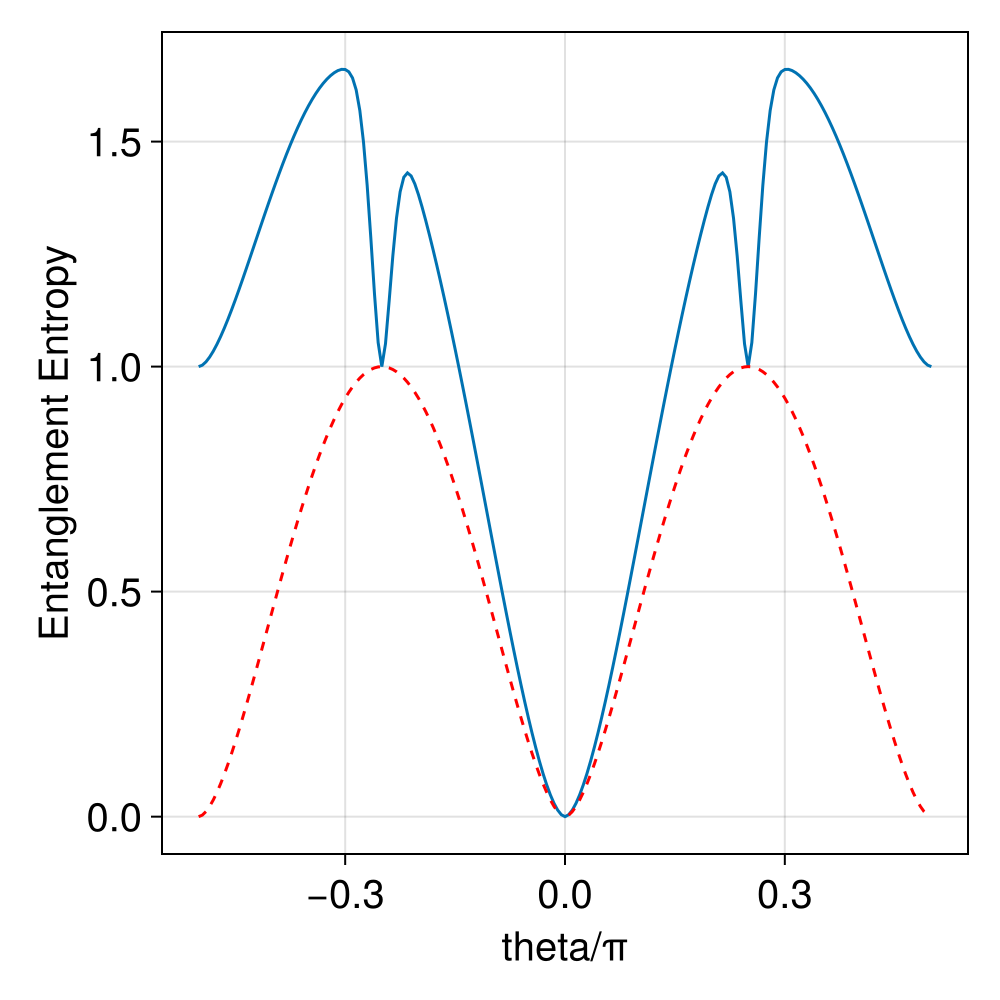

In [52]:
f = Figure(size=(500,500), fontsize=20)
Axis(f[1,1], xlabel="theta/π", ylabel="Entanglement Entropy")
lines!(thetas./pi, S, label="S(θ)")
lines!(thetas./pi, S_ana.(thetas), label="S_ana(θ)", linestyle=:dash, color=:red)
f

# Transverse-field Ising model

In [ ]:
using CairoMakie
using Makie.Colors
using Printf

In [16]:
function mps_ising_zz(N::Int64, Bx::Float64, Bz::Float64, chi::Int64, nsweeps::Int64, isobc::Bool=true, outputlevel::Int=1)
    J = 1.0 * 4
    h_perp = Bx * 2
    h_para = Bz * 2

    sites = siteinds("S=1/2", N)
  
    os = OpSum()
    for j=1:N-1
      os += -J,"Sz",j,"Sz",j+1
      os += -h_perp,"Sx",j
      os += (-h_para,"Sz",j)
    end
    if !isobc
        os += -J,"Sz",N,"Sz",1
    else
        nothing
    end
    os += -h_perp,"Sx",N
    os += (-h_para,"Sz",N)
    H = MPO(os,sites)
  
    psi0 = random_mps(sites;linkdims=chi)

    maxdim = [2^i<chi ? 2^i : chi for i=1:nsweeps]
    # maxdim = [chi for i in 1:nsweeps]
    cutoff = [1E-16]

    energy,psi = dmrg(H,psi0;nsweeps,maxdim,cutoff,outputlevel)

    return psi, energy
end

mps_ising_zz (generic function with 3 methods)

In [32]:
N_s = [20,50,100,1000]
isobc = true
chi = 50
nsweeps = 10
Bx_s = Array(0:0.02:2)

101-element Vector{Float64}:
 0.0
 0.02
 0.04
 0.06
 0.08
 0.1
 0.12
 0.14
 0.16
 0.18
 ⋮
 1.84
 1.86
 1.88
 1.9
 1.92
 1.94
 1.96
 1.98
 2.0

In [33]:
E_s = []
for Bx in Bx_s
    _, energy = mps_ising_zz(N_s[end], Bx, 0.0, chi, nsweeps, isobc, 0)
    push!(E_s, energy)
    println("--- ---")
end

--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---
--- ---


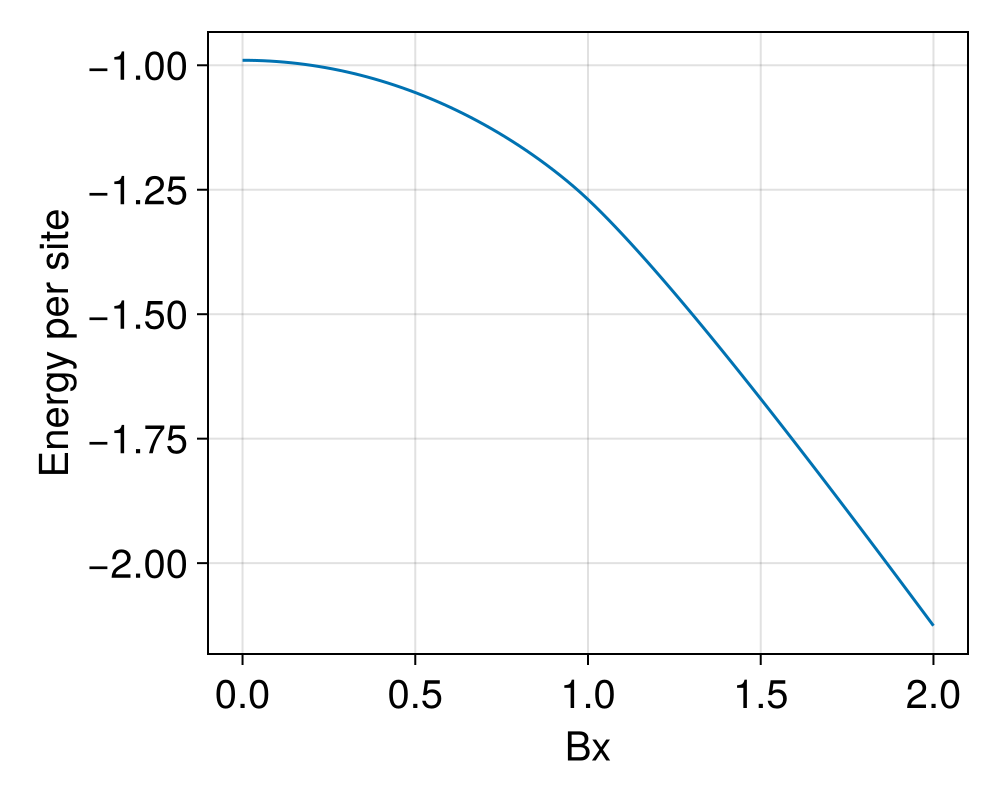

In [ ]:
f = Figure(size=(500,400), fontsize=20)
Axis(f[1,1], xlabel="Bx", ylabel="Energy per site")
lines!(Bx_s, E_s./N_s[end], label="N=100")
f

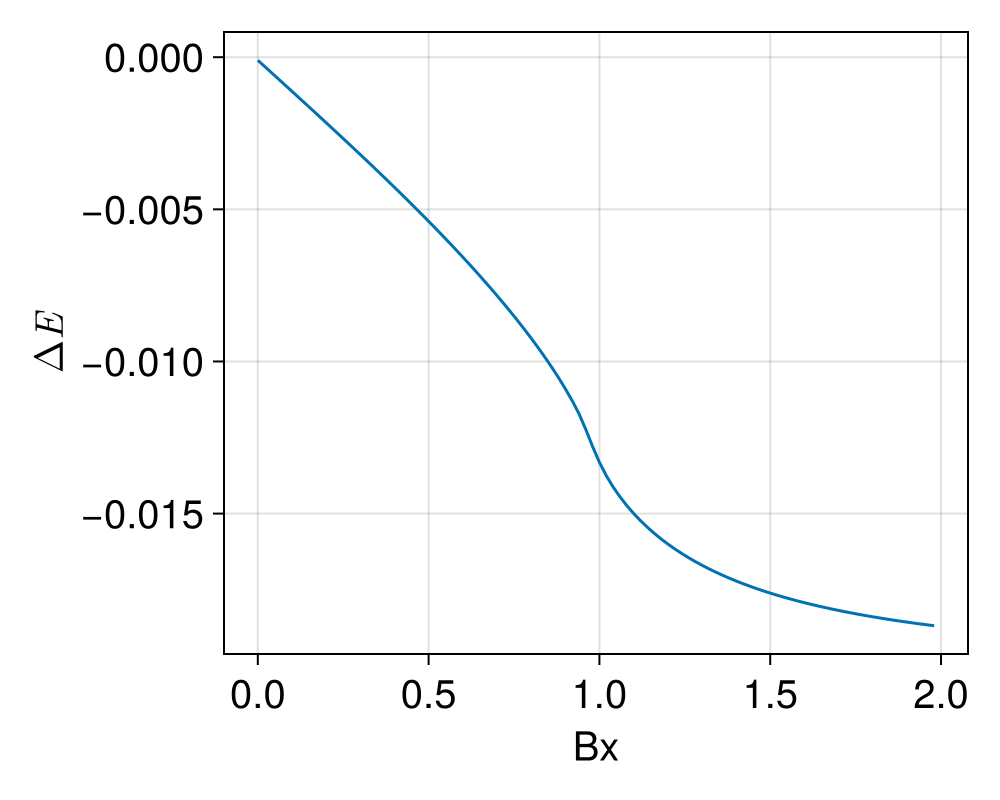

In [ ]:
dE_s = (E_s[2:end].-E_s[1:end-1])
f = Figure(size=(500,400), fontsize=20)
Axis(f[1,1], xlabel="Bx", ylabel=L"\Delta E")
lines!(Bx_s[1:end-1], dE_s./N_s[end], label="N=100")
f

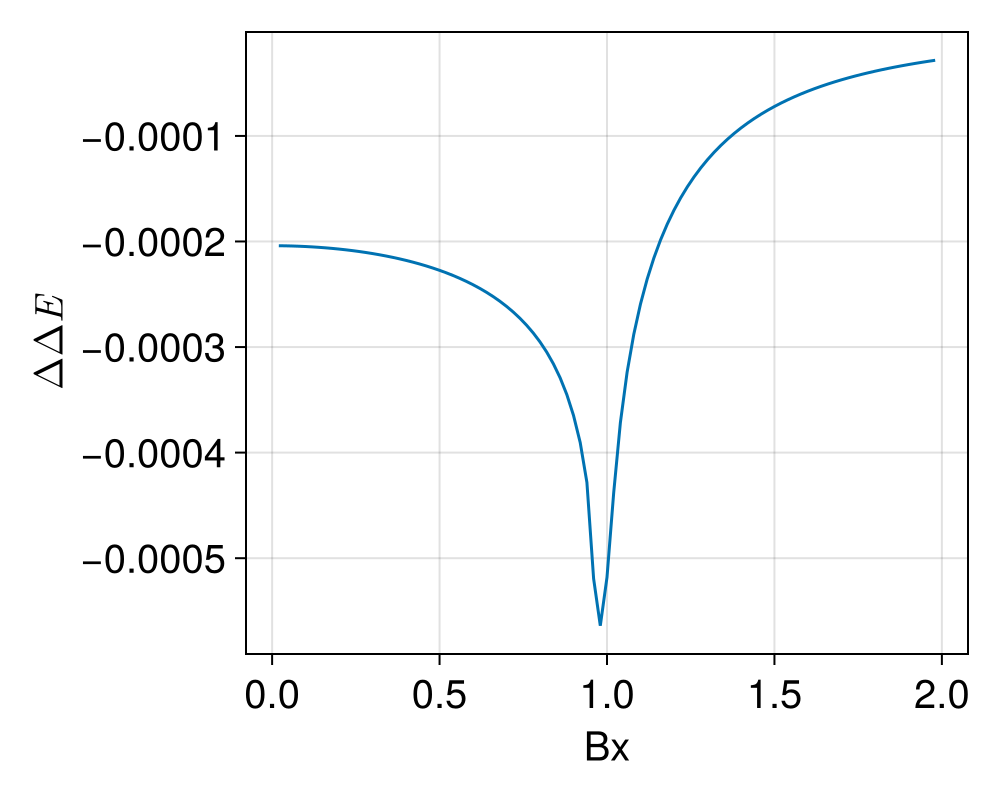

In [ ]:
ddE_s = (dE_s[2:end].-dE_s[1:end-1])
f = Figure(size=(500,400), fontsize=20)
Axis(f[1,1], xlabel="Bx", ylabel=L"\Delta\Delta E")
lines!(Bx_s[2:end-1], ddE_s./N_s[end], label="N=100")
f